## Introducing Deep Neural Networks 

Just 10 hidden layer. 

## Used libraries

In [1]:
from AmaroX.AmaroX.ai_functions import * 
from AmaroX.AmaroX.ai_models import * 
from AmaroX.AmaroX.data_manipulation import *
from AmaroX.AmaroX.utilities import *

import keras_tuner
import pandas as pd

2025-09-30 22:53:36.816719: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-30 22:53:37.626558: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/gaussian//g16/bsd:/opt/gaussian//g16:/opt/TeraChem/TeraChem/lib:/usr/local/cuda/lib64:/opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/intel/oneapi/tbb/2021.10.0/env/../lib/intel64/gcc4.8:/opt/intel/oneapi/mpi/2021.10.0//libfabric/lib:/opt/intel/oneapi/mpi/2021.10.0//lib/release:/opt/intel/oneapi/mpi/2021.10.0//lib:/opt/intel/oneapi/mkl/2023.2.0/lib/

## 1/10 Samples

In [2]:
n = 10
size = [
    1080000//n,
    108000//n, 
    12000//n
]

In [3]:
data = load_data_normalization_sample_General(
    '../../../../data_simulation/F2', 
    size = size
)

In [4]:
show_dimensions(data)


--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train: 
    x: (108000, 911, 1)
    y: (108000, 1)

Test: 
    x: (10800, 911, 1)
    y: (10800, 1)

Val:
    x: (1200, 911, 1)
    y: (1200, 1)
    


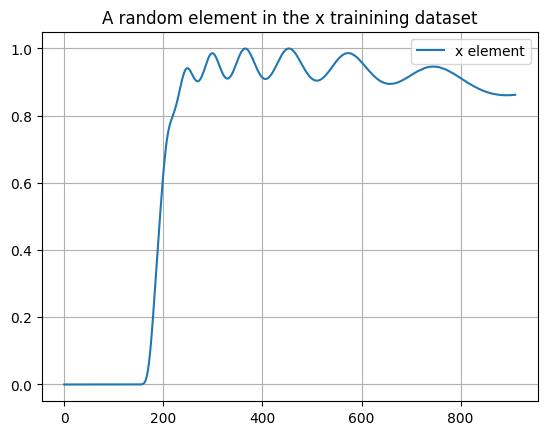

The corresponding y element -> [999.0296]


In [5]:
plot_xy(data)

In [6]:
x_train, y_train, x_test, y_test, x_val, y_val = data
del data 

## GPU Allocation

In [7]:
#! nvidia-smi

In [8]:
get_gpu(3)

2025-09-30 22:53:41.926255: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-30 22:53:42.869890: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30971 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


## Paths

In [9]:
name = 'DNN_HP_10'
folder_path = './models'
final_path = os.path.join(folder_path, name)

## Callbacks

In [10]:
callbacks = standard_callbacks(folder_name= name, 
                               folder_path= folder_path, 
                               patiences= [50, 1000])

## DNN Model

In [11]:
def _DNN(nodes:list):

    inputs = keras.layers.Input((911,))

    __DNN = G_Dense(
        inputs = inputs, 
        nodes = nodes,
        DP = 0,
        n_final = 1,
        act_func = 'leaky_relu', 
        final_act_func= 'relu', 
        WI= 'he_normal', 
        L1 = 0.0, 
        L2 = 0.0, 
        use_bias= True
    )

    return keras.models.Model(inputs = inputs, outputs = __DNN)

In [12]:
def compile_model(nodes: list, optimizer, modelo):

  model = modelo(nodes = nodes)

  model.compile(optimizer = optimizer,
                loss = 'mae',
                metrics = ['mape'])

  return model

In [13]:
def build_model(hp):

  nodes = [
      hp.Int('Nodes-1', min_value = 50, max_value = 500, step = 50), 
      hp.Int('Nodes-2', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-3', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-4', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-5', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-6', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-7', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-8', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-9', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-10', min_value = 50, max_value = 500, step = 50),
  ]

  #DP = hp.Int('Dropout', min_value = 0, max_value = 50, step = 2)

  #L1 = hp.Choice('L1', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  #L2 = hp.Choice('L2', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  optimizer = hp.Choice('optimizer', ['adam'])

  if optimizer == 'adam': opt = keras.optimizers.Adam(
        learning_rate = 0.001
    )

  elif optimizer == 'sgd': opt = keras.optimizers.SGD(
        learning_rate = 0.001
    )

  elif optimizer == 'adagrad': opt = keras.optimizers.Adagrad(
        learning_rate = 0.001
    )


  model_f = compile_model(nodes = nodes, optimizer = optimizer, modelo = _DNN)

  return model_f

In [14]:
build_model(keras_tuner.HyperParameters())

In [15]:
tuner = keras_tuner.BayesianOptimization(
    hypermodel=build_model,
    objective= keras_tuner.Objective('val_mape', 'min') ,
    max_trials= 50, # Set to 3
    executions_per_trial = 2,
    overwrite=True,
    directory= final_path,
    project_name="DNN-MI-KT",
)

In [16]:
tuner.search_space_summary()

Search space summary
Default search space size: 8
Nodes-1 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-2 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-3 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-4 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-5 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-6 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-7 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam'], 'ordered': False}


In [17]:
tuner.search(x_train[:,:,0], y_train, epochs=25, validation_data=(x_test[:,:,0], y_test), batch_size=512)


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
350               |350               |Nodes-1
500               |500               |Nodes-2
100               |100               |Nodes-3
200               |200               |Nodes-4
500               |500               |Nodes-5
250               |250               |Nodes-6
50                |50                |Nodes-7
adam              |adam              |optimizer

Epoch 1/25


2025-09-30 22:53:48.240782: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x2b5898033170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-30 22:53:48.240858: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100-PCIE-32GB, Compute Capability 7.0
2025-09-30 22:53:48.255355: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-30 22:53:48.569137: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


211/211 [==============================] - 12s 24ms/step - loss: 729.9392 - mape: 97.5837 - val_loss: 735.4255 - val_mape: 99.9938
Epoch 2/25
211/211 [==============================] - 4s 21ms/step - loss: 713.2111 - mape: 93.6172 - val_loss: 735.3561 - val_mape: 99.9605
Epoch 3/25
211/211 [==============================] - 4s 21ms/step - loss: 685.0180 - mape: 87.1440 - val_loss: 601.0714 - val_mape: 69.8696
Epoch 4/25
211/211 [==============================] - 4s 20ms/step - loss: 644.9365 - mape: 79.0102 - val_loss: 576.3577 - val_mape: 69.8829
Epoch 5/25
211/211 [==============================] - 4s 21ms/step - loss: 594.6957 - mape: 72.1356 - val_loss: 730.7629 - val_mape: 98.1559
Epoch 6/25
211/211 [==============================] - 4s 20ms/step - loss: 532.9742 - mape: 70.2615 - val_loss: 718.6877 - val_mape: 95.3622
Epoch 7/25
211/211 [==============================] - 4s 20ms/step - loss: 460.1283 - mape: 61.9040 - val_loss: 735.4424 - val_mape: 100.0000
Epoch 8/25
211/211 [==

KeyboardInterrupt: 

In [ ]:
file_path = os.path.join(final_path, 'best_models.txt')

with open(file_path, "w") as file:
    # Save the original stdout
    original_stdout = sys.stdout
    try:
        sys.stdout = file  # Redirect stdout to the file
        tuner.results_summary()  # Call your function
    finally:
        sys.stdout = original_stdout

